## FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

#### Objective:

Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset. 


#### Dataset:

The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.


#### Part 1: Data Preparation and Exploration

##### 1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

In [6]:
import pandas as pd

# File path
file_path = r"C:\Users\Rakshitha\Downloads\exchange_rate.csv"

# Load dataset and parse date column
df = pd.read_csv(file_path, parse_dates=['date'])

# Display first few rows
print(df.head())

               date  Ex_rate
0  01-01-1990 00:00   0.7855
1  02-01-1990 00:00   0.7818
2  03-01-1990 00:00   0.7867
3  04-01-1990 00:00   0.7860
4  05-01-1990 00:00   0.7849


##### 2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

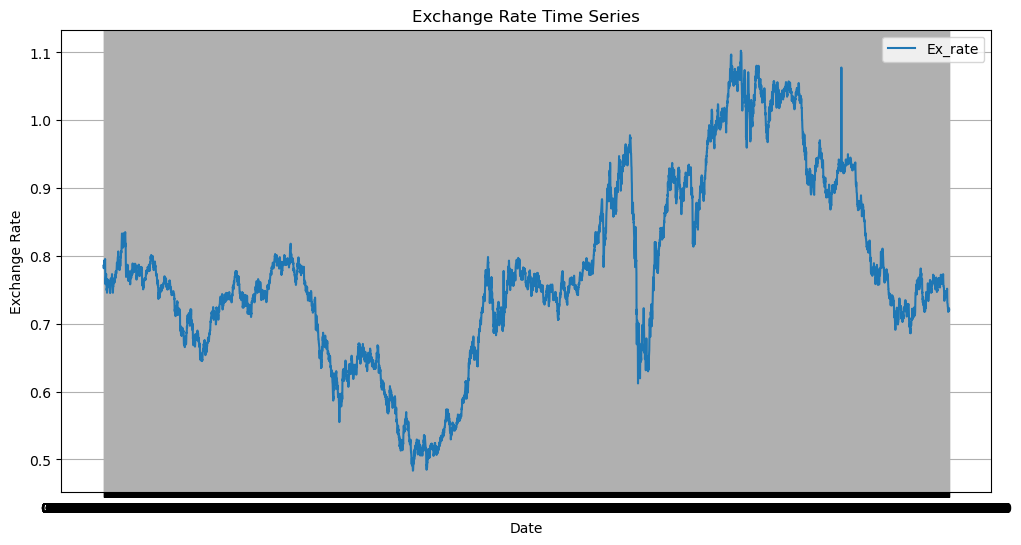

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\exchange_rate.csv"
df = pd.read_csv(file_path, parse_dates=['date'])

# Set date as index
df.set_index('date', inplace=True)

# Plot all currency columns
plt.figure(figsize=(12, 6))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)

plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

##### 3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [8]:
import pandas as pd


# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\exchange_rate.csv"
df = pd.read_csv(file_path, parse_dates=['date'])

# Set date as index
df.set_index('date', inplace=True)

# Check missing values
print("Missing values before handling:\n", df.isnull().sum())

# Handle missing values using forward fill then backward fill
df = df.ffill().bfill()

# (Optional) Remove outliers using IQR method
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

# Check missing values after handling
print("Missing values after handling:\n", df.isnull().sum())

# Display cleaned data
print(df.head())

Missing values before handling:
 Ex_rate    0
dtype: int64
Missing values after handling:
 Ex_rate    0
dtype: int64
                  Ex_rate
date                     
01-01-1990 00:00   0.7855
02-01-1990 00:00   0.7818
03-01-1990 00:00   0.7867
04-01-1990 00:00   0.7860
05-01-1990 00:00   0.7849


#### Part 2: Model Building - ARIMA

##### 1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

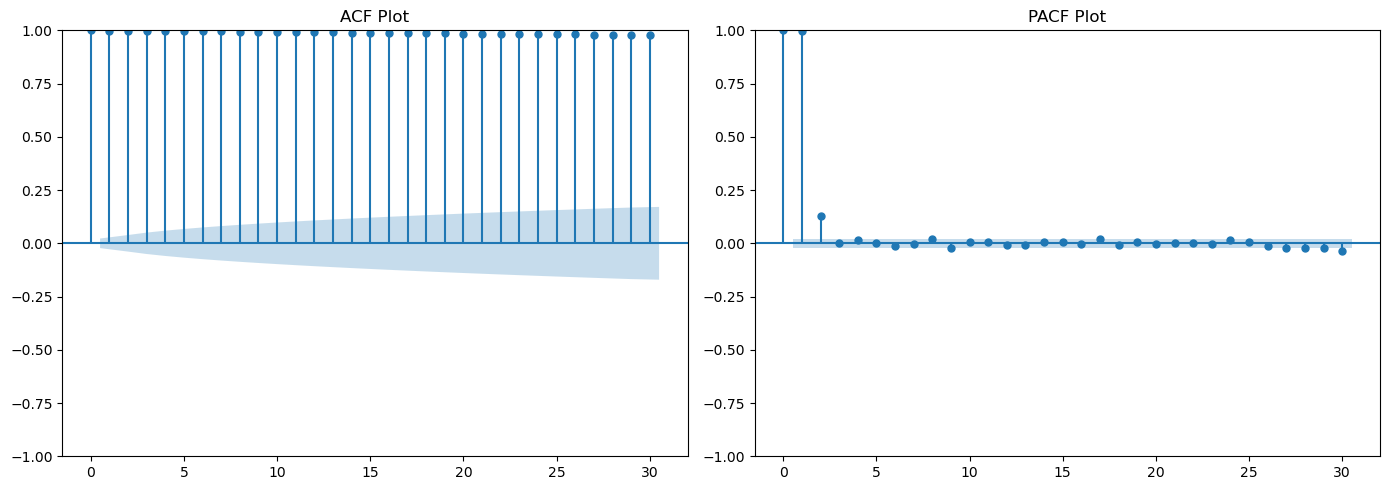

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\exchange_rate.csv"
df = pd.read_csv(file_path, parse_dates=['date'])

# Set date as index
df.set_index('date', inplace=True)

# Select one currency column (change column name if needed)
series = df[df.columns[0]].dropna()

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, ax=axes[0], lags=30)
axes[0].set_title("ACF Plot")

plot_pacf(series, ax=axes[1], lags=30, method='ywm')
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

##### 2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

In [19]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\exchange_rate.csv"
df = pd.read_csv(file_path, parse_dates=['date'])

# Set index
df.set_index('date', inplace=True)

# Sort data
df = df.sort_index()

# DO NOT force asfreq (this is causing empty dataset issues)
# Instead, directly handle missing values
df = df.fillna(method='ffill').fillna(method='bfill')

# Select one currency column
series = df[df.columns[0]]

# Drop any remaining NaNs
series = series.dropna()

# Check data size (IMPORTANT)
print("Number of observations:", len(series))

# Prevent crash if data is too small
if len(series) < 20:
    raise ValueError("Not enough data after cleaning. Need at least 20+ observations.")

# Fit ARIMA model
model = ARIMA(series, order=(1, 1, 1))
model_fit = model.fit()

# Print summary
print(model_fit.summary())

C:\Users\Rakshitha\AppData\Local\Temp\ipykernel_17616\2001074419.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be gene

Number of observations: 7588


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood                7260.780
Date:                Thu, 09 Apr 2026   AIC                         -14515.559
Time:                        12:29:19   BIC                         -14494.757
Sample:                             0   HQIC                        -14508.420
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7335      0.009     79.740      0.000       0.715       0.752
ma.L1         -1.0000      0.168     -5.937      0.000      -1.330      -0.670
sigma2         0.0086      0.001      5.899      0.0

##### 3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Ch

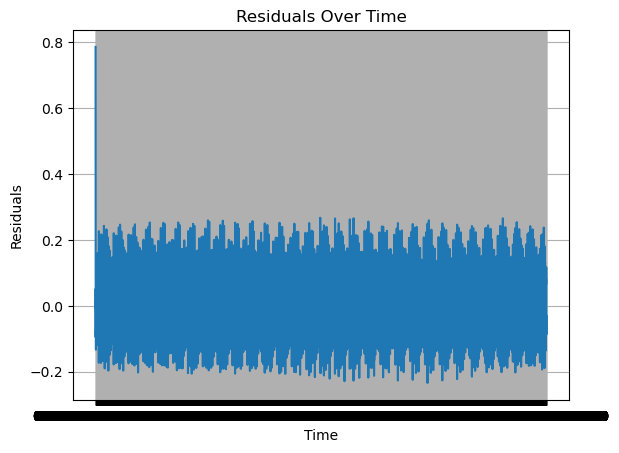

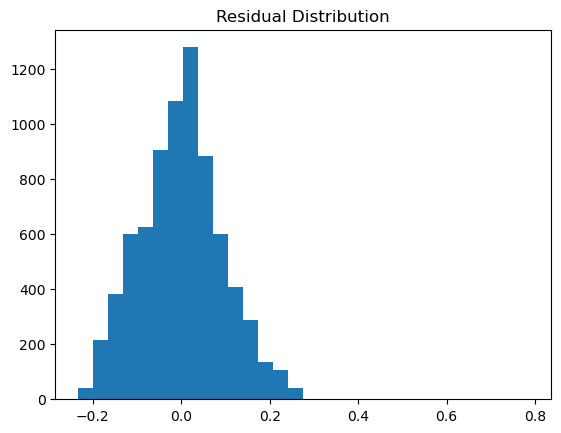

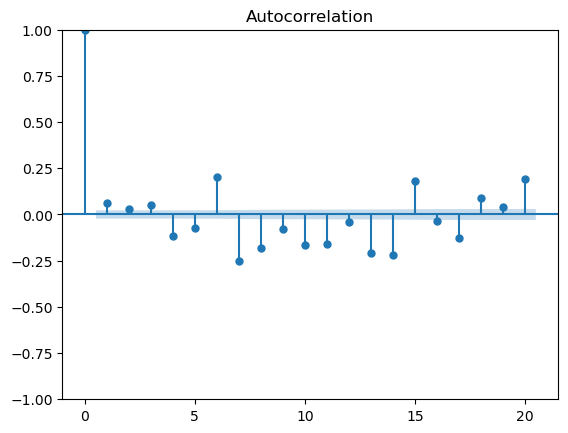

        lb_stat  lb_pvalue
10  1497.426002        0.0


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\exchange_rate.csv"
df = pd.read_csv(file_path, parse_dates=['date'])

# Set index and sort
df.set_index('date', inplace=True)
df = df.sort_index()

# Handle missing values
df = df.ffill().bfill()

# Select one currency series
series = df[df.columns[0]].dropna()

# Fit ARIMA model
model = ARIMA(series, order=(1, 1, 1))
model_fit = model.fit()

# Extract residuals
residuals = model_fit.resid

# 1. Residuals over time
plt.figure()
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

# 2. Histogram of residuals
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

# 3. ACF of residuals
plot_acf(residuals, lags=20)
plt.show()

# 4. Ljung-Box test
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

##### 4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results 

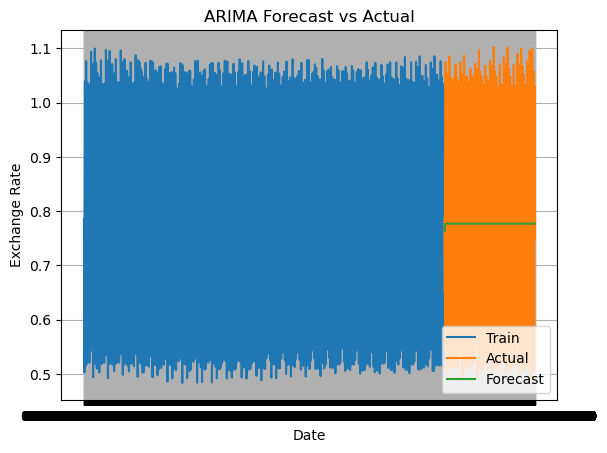

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\exchange_rate.csv"
df = pd.read_csv(file_path, parse_dates=['date'])

# Set index and sort
df.set_index('date', inplace=True)
df = df.sort_index()

# Handle missing values
df = df.ffill().bfill()

# Select one currency series
series = df[df.columns[0]].dropna()

# Train-test split (80% train, 20% test)
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Fit ARIMA model on training data
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Forecast on test period
forecast = model_fit.forecast(steps=len(test))

# Plot actual vs predicted
plt.figure()
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

#### Part 3: Evaluation and Comparison

##### 1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming you already have:
# test -> actual values
# forecast -> predicted values from ARIMA

# Ensure both are aligned
test_values = test.values
forecast_values = forecast.values

# MAE
mae = mean_absolute_error(test_values, forecast_values)

# RMSE
rmse = np.sqrt(mean_squared_error(test_values, forecast_values))

# MAPE
mape = np.mean(np.abs((test_values - forecast_values) / test_values)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.10510029943741565
RMSE: 0.13711047386468453
MAPE: 14.034225972105732


##### 2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

##### Performance Analysis

MAE (Mean Absolute Error):

Indicates the average magnitude of errors in the predictions. A lower MAE means the model’s predictions are closer to actual values.
    
RMSE (Root Mean Squared Error):

Penalizes larger errors more heavily. If RMSE is significantly higher than MAE, it suggests the presence of some large deviations in predictions.
    
MAPE (Mean Absolute Percentage Error):

Expresses error as a percentage. Lower MAPE indicates better predictive accuracy and is useful for interpretability.

##### Advantages of ARIMA

Works well for univariate time series data

Captures trend and autocorrelation effectively

Does not require large datasets

Provides statistically interpretable parameters (p, d, q)

Suitable for short-term forecasting

##### Limitations of ARIMA

Assumes the time series is stationary (requires differencing)

Cannot handle seasonality unless extended to SARIMA

Performs poorly with non-linear patterns

Sensitive to parameter selection (p, d, q)

Limited performance on complex or highly volatile datasets

Requires sufficient and clean data; struggles with small datasets